# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Nguyễn Tuấn Kiệt"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600233"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
display_student_header()

# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://fragrance-lower-bull-buddy.trycloudflare.com"
# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
display_student_header()

nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 7 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 72.9% | Mem: 12.8/16.0GB | Power: 46W | Temp: 79°C
   GPU 1 [T4] 🔴 Util: 70.1% | Mem: 11.2/16.0GB | Power: 61W | Temp: 67°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 84.4% | Mem: 65.4/80.0GB | Power: 253W | Temp: 82°C
   GPU 1 [A100] 🔴 Util: 71.5% | Mem: 69.4/80.0GB | Power: 260W | Temp: 58°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 65.4% | Mem: 25.6/32.0GB | Power: 222W | Temp: 57°C
   GPU 1 [V100] 🟢 Util: 7.4% | Mem: 1.0/32.0GB | Power: 38W | Temp: 30°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 61.9% | Mem: 14.0/16.0GB | Power: 45W | Temp: 77°C
   GPU 1 [T4] 🔴 Util: 60.2% | Mem: 14.4/16.0GB | Power: 62W | Temp: 56°C

🖥️  node-04:
   GPU 0 [T4] 🔴 Util: 73.0% | Mem: 9.0/16.0GB | Power: 56W | Temp: 73°C
   GPU 1 [T4] 🔴 Util: 61.3% | Mem: 12.7/16.0GB | Power: 49W | Temp: 74°C

🖥️  node-05:
   GPU 0 [T4] 🔴 Util: 67.2% | Mem: 8.1/16.0GB | Power: 54W | Temp: 69°C
   GPU 1 [T4] 🔴 Util: 60.7% | Mem: 11.7/16.0GB | Power: 54W | Temp: 63°C

🖥️  node-0

In [5]:
# Cell 4: Cluster Metrics Summary
display_student_header()

metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          14
Busy GPUs:           11
Idle GPUs:           3
Avg Utilization:     54.0%
Memory Used:         256.4 GB
Memory Capacity:     384.0 GB
Total Power Draw:    1239 W
Node Count:          7


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
display_student_header()

workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-06', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-06', 'gpu_id': 1}]
   train-llm-004: queued → queued

📊 Updated metrics:
   Busy GPUs: 14/14 | Utilization: 69.5%


In [7]:
# Cell 6: Record billing for workloads
display_student_header()

billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $3.9229
   Total Savings:  $4.1229
   Budget Used:    3.9%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
display_student_header()

spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2615     25.3    % high
A100       $3.67       $2.7073     26.2    % high
V100       $2.48       $1.9399     21.8    % low


In [9]:
# Cell 8: Request spot instances
display_student_header()

spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
# Cell 9: Simulate spot preemption
display_student_header()

print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 5

   ⚠️  Preempted:
      - spot-t4-002 (ran for 1s, 120s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0512
   On-demand equiv:  $0.1707
   Total saved:      $0.1195 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
display_student_header()

policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
# Cell 11: Trigger autoscaler evaluation
display_student_header()

print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 69.5% within thresholds [25.0-70.0%]
   Current utilization: 69.5%
   Nodes: 7 → 7

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 69.5% | Nodes: 7→7
   Cycle 2: no_action    | Util: 69.5% | Nodes: 7→7
   Cycle 3: no_action    | Util: 69.5% | Nodes: 7→7
   Cycle 4: no_action    | Util: 69.5% | Nodes: 7→7
   Cycle 5: no_action    | Util: 69.5% | Nodes: 7→7


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
display_student_header()

print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.043889 | Idle=$0.000000 | Waste=0.0%
   Snapshot 2: Total=$0.043889 | Idle=$0.000000 | Waste=0.0%
   Snapshot 3: Total=$0.043889 | Idle=$0.000000 | Waste=0.0%
   Snapshot 4: Total=$0.043889 | Idle=$0.000000 | Waste=0.0%
   Snapshot 5: Total=$0.043889 | Idle=$0.000000 | Waste=0.0%


In [14]:
# Cell 13: Waste Report
display_student_header()

waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          3.9%
   Total Idle Cost:        $0.016609
   Total Cost:             $0.433055
   Potential Monthly Save:  $430.51
   Severity:               LOW


In [15]:
# Cell 14: Get Optimization Recommendations
display_student_header()

recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
# Cell 15: Full Dashboard View
display_student_header()

dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 14 GPUs across 7 nodes
   Utilization: 69.5% | Busy: 14 | Idle: 0

💰 BILLING: $3.9229 / $100.00 budget
   Alert: OK | Savings: $4.1229

🎯 SPOT: Saved $0.1405 (70.0%)

🗑️  WASTE: 3.9% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

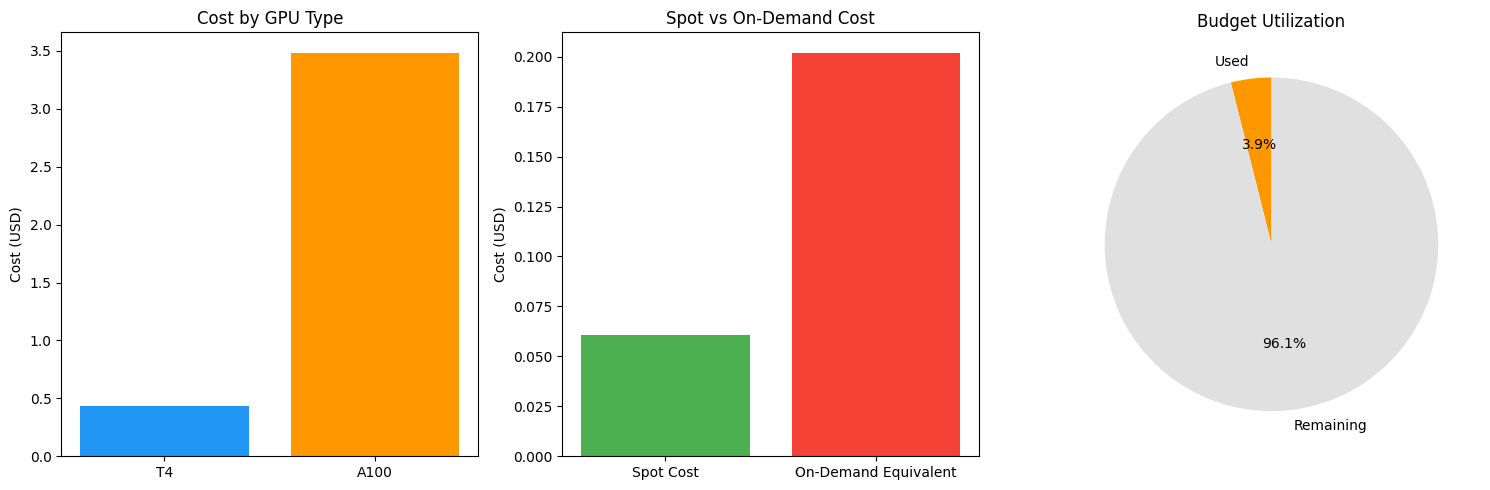

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
display_student_header()

summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


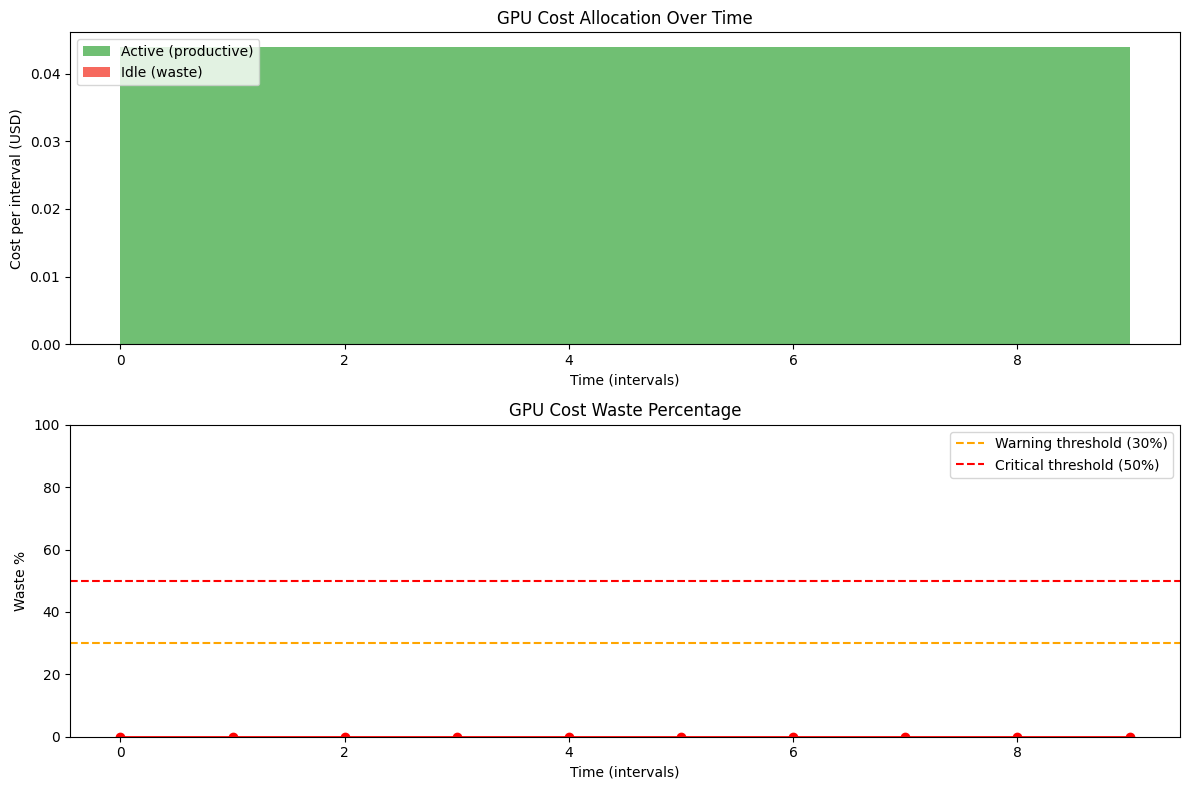

In [18]:
# Cell 17: Time-series cost tracking
display_student_header()

print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
display_student_header()

print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 14 | Util: 69.5% | Idle: 0

2️⃣  Submitting heavy workloads...
   After load: Util: 69.5% | Busy: 14/14

3️⃣  Autoscaler evaluation:
   Decision: no_action - Utilization 69.5% within thresholds [25.0-70.0%]

4️⃣  Cost analysis:
   Total cost/interval: $0.043889
   Waste: 0.0%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0361 (70.0%)

7️⃣  Final billing:
   Total spend: $4.0920
   Total saved: $4.2453
   Budget: 4.1% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install dependencies & detect real GPU
display_student_header()

!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [21]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
display_student_header()

# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.7W
   Temp: 38C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.664
   temp_c: 38.0

   Method: pynvml

Ready for training.


In [22]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
display_student_header()

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:01<00:00, 95.9MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
display_student_header()

NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.7905 | Acc: 34.8% | Time: 41.3s | Samples: 40
   Epoch 2/3 | Loss: 1.2695 | Acc: 54.1% | Time: 41.0s | Samples: 40
   Epoch 3/3 | Loss: 0.9841 | Acc: 64.9% | Time: 44.9s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      127.2s
   Peak memory:     0.82 GB
   Avg GPU util:    94.8%
   Avg power:       66.4W
   Avg temperature: 62.8C
   Max GPU util:    98.0%
   Estimated cost:  $0.012371


In [24]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
display_student_header()

print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/4291706368.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/4291706368.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9384 | Acc: 30.4% | Time: 22.4s | Samples: 40
   Epoch 2/3 | Loss: 1.3835 | Acc: 49.2% | Time: 21.4s | Samples: 40
   Epoch 3/3 | Loss: 1.0630 | Acc: 62.2% | Time: 20.7s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      64.5s
   Peak memory:     0.60 GB
   Avg GPU util:    88.6%
   Avg power:       65.0W
   Avg temperature: 77.6C
   Max GPU util:    93.0%
   Estimated cost:  $0.006266


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                127.2           64.5            1.97x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012371       $0.006266       $0.006105 saved
Cost Saving %             ---             ---             49.3%
Avg GPU Util %            94.8            88.6           
Avg Power (W)             66.4            65.0           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.25 -> SAVE $4.15
   1 week training: FP32=$58.80 vs AMP=$29.78 -> SAVE $29.02
   1 month training: FP32=$252.00 vs AMP=$127.64 -> SAVE $124.36


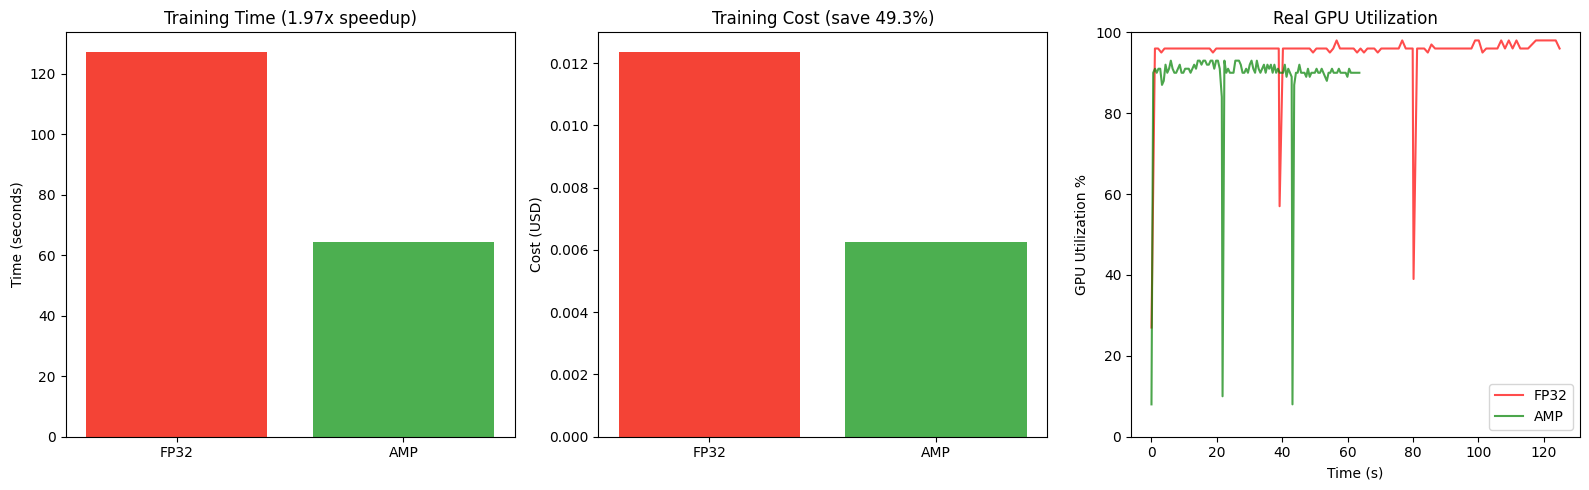

In [25]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
display_student_header()

print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
display_student_header()

print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012400 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001900 | Saved: $0.004400

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.028700
   Total Savings:   $0.008700
   Workloads:       4

   Cost snapshot taken: waste=15.7%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $4.0920
   Total Savings:        $4.2453
   Budget Utilization:   4.1%
   Alert:                OK


Real GPU Telemetry During Training


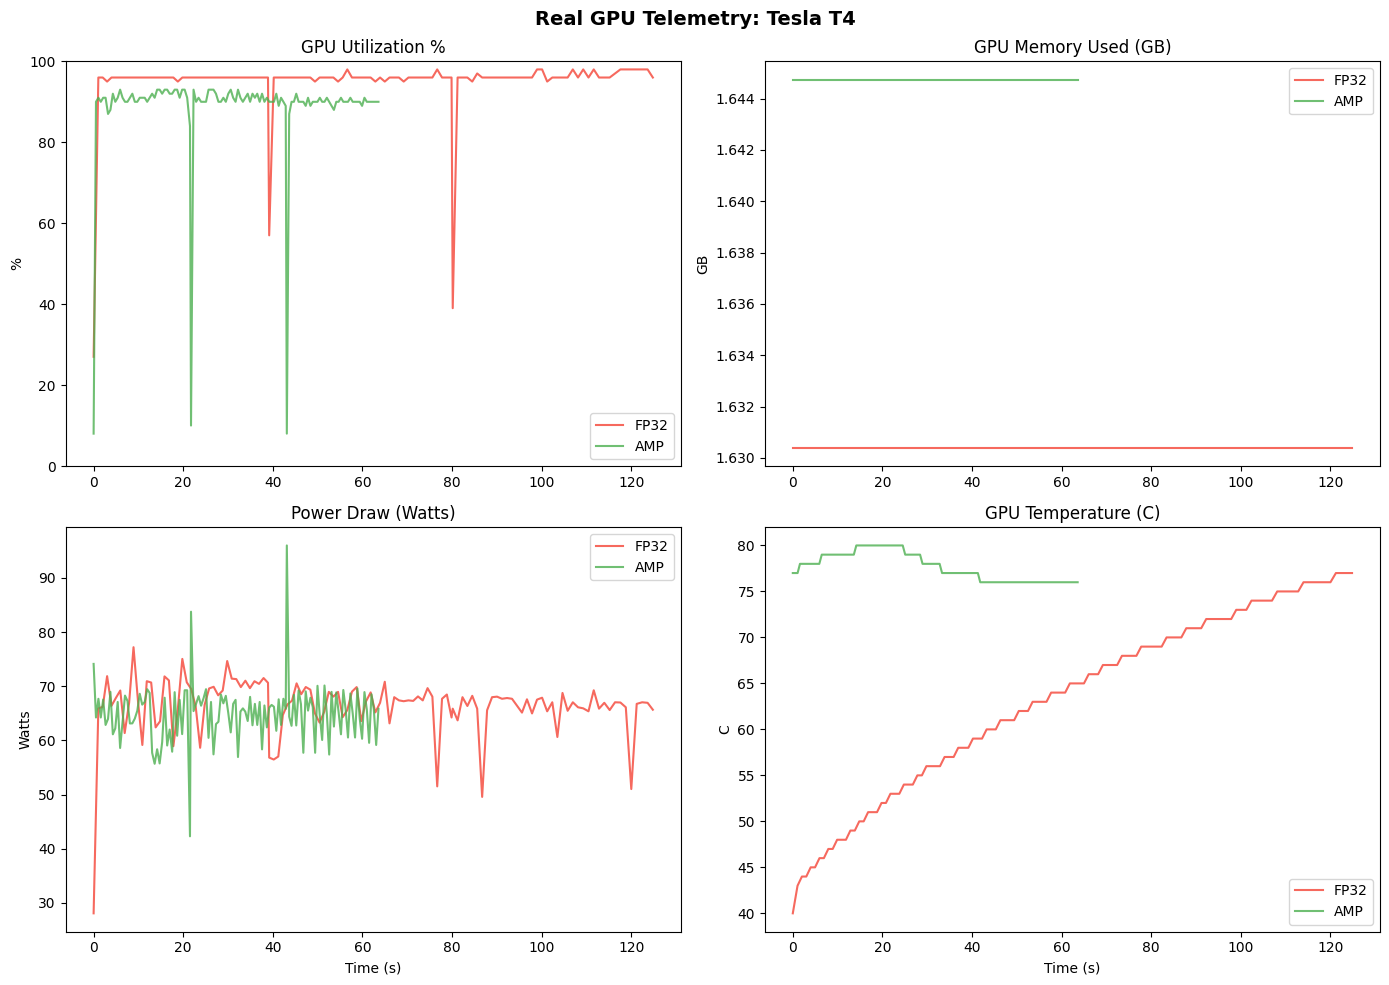

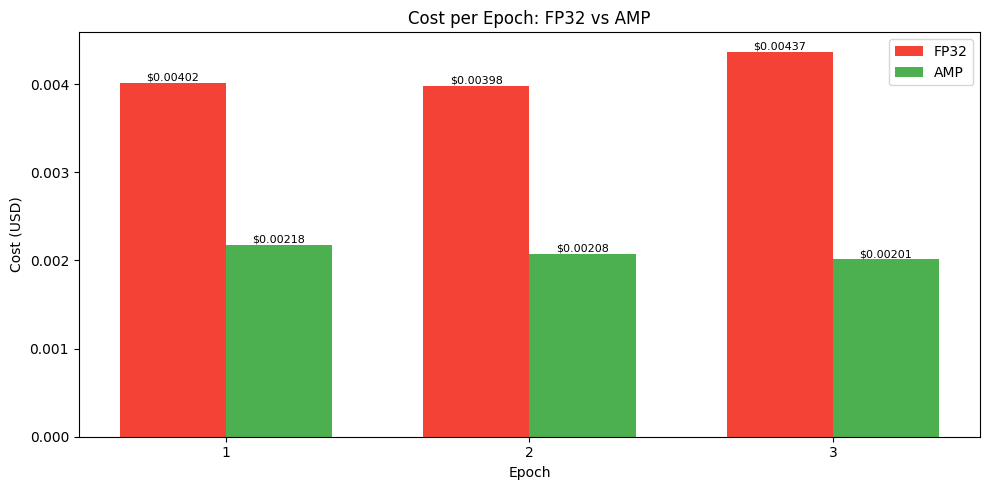


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [27]:
# Cell 26: Real GPU Monitoring Visualization
display_student_header()

print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [28]:
# Cell 27: Multi-GPU Cost Analysis
display_student_header()

print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

# ── Multi-GPU Cost Analysis ────────────────────────────────────────────────
# Assumptions:
# - GPU_PRICING contains hourly price per GPU
# - Scaling efficiency becomes worse as GPU count increases
# - Cost-performance ratio:
#       total_cost / achieved_speedup
#   Lower value = better efficiency
#
# Example:
#   2 GPUs rarely give exact 2x speedup because of:
#   - communication overhead
#   - synchronization cost
#   - dataloader bottlenecks

def analyze_multi_gpu_cost(
    base_time_hours,
    gpu_type,
    gpu_counts,
    scaling_factors=None
):
    """
    Analyze training cost and efficiency across multiple GPU counts.

    Parameters:
        base_time_hours (float):
            Single-GPU training time in hours.

        gpu_type (str):
            GPU type key from GPU_PRICING.

        gpu_counts (list[int]):
            GPU counts to evaluate.

        scaling_factors (dict[int, float] | None):
            Mapping:
                gpu_count -> achieved speedup

            Example:
                {
                    1: 1.0,
                    2: 1.8,
                    4: 3.2,
                    8: 5.8
                }

    Returns:
        dict:
            Multi-GPU analysis results.
    """

    # ── Guards ─────────────────────────────────────────────────────────────
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown GPU type: {gpu_type}")

    if base_time_hours <= 0:
        raise ValueError("base_time_hours must be positive")

    if not gpu_counts:
        raise ValueError("gpu_counts cannot be empty")

    # ── Default realistic scaling ─────────────────────────────────────────
    # Key:
    #   gpu_count
    #
    # Value:
    #   actual achieved speedup
    #
    # Example:
    #   4 GPUs -> 3.2x faster instead of perfect 4x
    if scaling_factors is None:
        scaling_factors = {
            1: 1.0,
            2: 1.8,
            4: 3.2,
            8: 5.8
        }

    # ── Base price lookup ─────────────────────────────────────────────────
    gpu_hourly_price = GPU_PRICING[gpu_type]

    # ── Result container ──────────────────────────────────────────────────
    analysis = {}

    # ── Compute metrics ───────────────────────────────────────────────────
    for gpu_count in gpu_counts:

        # Fallback scaling:
        # use 70% efficiency if count missing
        if gpu_count not in scaling_factors:
            achieved_speedup = gpu_count * 0.7
        else:
            achieved_speedup = scaling_factors[gpu_count]

        # Training time after parallelization
        training_time_hours = (
            base_time_hours / achieved_speedup
        )

        # Total cluster cost
        total_cost = (
            training_time_hours
            * gpu_hourly_price
            * gpu_count
        )

        # Parallel efficiency:
        #   actual_speedup / ideal_speedup
        parallel_efficiency = (
            achieved_speedup / gpu_count
        )

        # Cost normalized by performance gain
        cost_per_speedup = (
            total_cost / achieved_speedup
        )

        # Store result
        analysis[gpu_count] = {
            "speedup": achieved_speedup,
            "training_time_hours": training_time_hours,
            "total_cost": total_cost,
            "parallel_efficiency": parallel_efficiency,
            "cost_per_speedup": cost_per_speedup
        }

    return analysis


# ── Test Data ─────────────────────────────────────────────────────────────
base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]

# Example pricing table
GPU_PRICING = {
    "T4": 0.35,
    "A100": 3.50
}

# ── Run Analysis ──────────────────────────────────────────────────────────
results = analyze_multi_gpu_cost(
    base_time_hours=base_training_time,
    gpu_type="A100",
    gpu_counts=test_gpu_counts
)

# ── Display Results ───────────────────────────────────────────────────────
print("\nGPU Cost Analysis\n")

header = (
    f"{'GPUs':<8}"
    f"{'Speedup':<12}"
    f"{'Time(h)':<12}"
    f"{'Cost($)':<12}"
    f"{'Efficiency':<14}"
    f"{'Cost/Perf':<12}"
)

print(header)
print("-" * len(header))

best_gpu_count = None
best_ratio = float("inf")

for gpu_count in test_gpu_counts:

    result = results[gpu_count]

    speedup = result["speedup"]
    time_h = result["training_time_hours"]
    cost_usd = result["total_cost"]
    efficiency = result["parallel_efficiency"]
    cost_perf = result["cost_per_speedup"]

    row = (
        f"{gpu_count:<8}"
        f"{speedup:<12.2f}"
        f"{time_h:<12.2f}"
        f"{cost_usd:<12.2f}"
        f"{efficiency:<14.2%}"
        f"{cost_perf:<12.2f}"
    )

    print(row)

    if cost_perf < best_ratio:
        best_ratio = cost_perf
        best_gpu_count = gpu_count

# ── Summary ───────────────────────────────────────────────────────────────
print("\nOptimal Configuration")
print(f"Most cost-efficient GPU count: {best_gpu_count}")
print(f"Lowest cost/performance ratio: {best_ratio:.2f}")

EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU Cost Analysis

GPUs    Speedup     Time(h)     Cost($)     Efficiency    Cost/Perf   
----------------------------------------------------------------------
1       1.00        2.00        7.00        100.00%       7.00        
2       1.80        1.11        7.78        90.00%        4.32        
4       3.20        0.62        8.75        80.00%        2.73        
8       5.80        0.34        9.66        72.50%        1.66        

Optimal Configuration
Most cost-efficient GPU count: 8
Lowest cost/performance ratio: 1.66


In [30]:
# Cell 28: Project Cost Forecasting
display_student_header()

print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import math

# TODO: Implement project cost forecasting with confidence intervals
# Hint: ML projects have multiple phases (data prep, training, tuning, deployment)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase ML project costs with uncertainty bounds.

    Assumptions:
    - GPU_PRICING contains hourly rates:
        GPU_PRICING[gpu_type]["hourly_rate"]
    - uncertainty_pct represented as decimal:
        0.20 = ±20%
    - Phase uncertainties independent.
    """

    # ── 1. Confidence Z-Scores ──────────────────────────────────────────────
    z_lookup = {
        0.80: 1.28,
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576,
    }

    z_score = z_lookup.get(confidence_level, 1.96)

    # ── 2. Aggregate Containers ─────────────────────────────────────────────
    phase_breakdown = []

    total_base_cost = 0.0
    total_variance = 0.0

    # ── 3. Phase Cost Calculation ───────────────────────────────────────────
    for phase in phases:

        phase_name = phase["name"]
        gpu_type = phase["gpu_type"]
        gpu_count = phase["gpu_count"]
        duration_hours = phase["duration_hours"]
        uncertainty_pct = phase["uncertainty_pct"]

        # Guard: invalid gpu type
        if gpu_type not in GPU_PRICING:
            raise ValueError(f"Unknown GPU type: {gpu_type}")

        hourly_rate = GPU_PRICING[gpu_type]

        # Base deterministic cost
        base_cost = hourly_rate * gpu_count * duration_hours

        # Standard deviation estimate from uncertainty %
        std_dev = base_cost * uncertainty_pct

        # Variance aggregation
        variance = std_dev ** 2

        # Confidence interval
        ci_margin = z_score * std_dev

        best_case = max(0, base_cost - ci_margin)
        worst_case = base_cost + ci_margin

        # Aggregate totals
        total_base_cost += base_cost
        total_variance += variance

        # Store phase output
        phase_breakdown.append({
            "name": phase_name,
            "gpu_type": gpu_type,
            "gpu_count": gpu_count,
            "duration_hours": duration_hours,
            "base_cost": base_cost,
            "uncertainty_pct": uncertainty_pct,
            "best_case": best_case,
            "worst_case": worst_case,
        })

    # ── 4. Portfolio-Level Uncertainty ──────────────────────────────────────
    total_std_dev = math.sqrt(total_variance)

    total_ci_margin = z_score * total_std_dev

    contingency_cost = total_base_cost * (contingency_pct / 100)

    total_with_contingency = total_base_cost + contingency_cost

    portfolio_best_case = max(0, total_base_cost - total_ci_margin)
    portfolio_worst_case = total_base_cost + total_ci_margin

    # ── 5. Compose Result ───────────────────────────────────────────────────
    result = {
        "confidence_level": confidence_level,
        "phase_breakdown": phase_breakdown,
        "base_total_cost": total_base_cost,
        "contingency_pct": contingency_pct,
        "contingency_cost": contingency_cost,
        "forecast_total": total_with_contingency,
        "best_case_total": portfolio_best_case,
        "worst_case_total": portfolio_worst_case,
    }

    return result


# Example project phases
example_project = [
    {
        "name": "Data Preparation",
        "gpu_type": "T4",
        "gpu_count": 1,
        "duration_hours": 40,
        "uncertainty_pct": 0.15
    },
    {
        "name": "Model Training",
        "gpu_type": "A100",
        "gpu_count": 4,
        "duration_hours": 120,
        "uncertainty_pct": 0.25
    },
    {
        "name": "Hyperparameter Tuning",
        "gpu_type": "A100",
        "gpu_count": 8,
        "duration_hours": 60,
        "uncertainty_pct": 0.30
    },
    {
        "name": "Model Evaluation",
        "gpu_type": "T4",
        "gpu_count": 2,
        "duration_hours": 20,
        "uncertainty_pct": 0.10
    },
]

# ── 6. Run Forecast ────────────────────────────────────────────────────────
forecast = forecast_project_cost(
    phases=example_project,
    contingency_pct=20,
    confidence_level=0.95
)

# ── 7. Display Results ─────────────────────────────────────────────────────
print("\n📊 PROJECT COST FORECAST")
print("-" * 60)

for phase in forecast["phase_breakdown"]:

    print(f"\nPhase: {phase['name']}")
    print(f"GPU Type: {phase['gpu_type']}")
    print(f"GPU Count: {phase['gpu_count']}")
    print(f"Duration: {phase['duration_hours']} hours")

    print(f"Base Cost: ${phase['base_cost']:.2f}")
    print(f"Best Case: ${phase['best_case']:.2f}")
    print(f"Worst Case: ${phase['worst_case']:.2f}")

    print(f"Uncertainty: ±{phase['uncertainty_pct'] * 100:.1f}%")

print("\n" + "=" * 60)
print("TOTAL PROJECT FORECAST")
print("=" * 60)

print(f"Base Total Cost: ${forecast['base_total_cost']:.2f}")

print(
    f"Contingency Buffer ({forecast['contingency_pct']}%): "
    f"${forecast['contingency_cost']:.2f}"
)

print(f"Forecast Total: ${forecast['forecast_total']:.2f}")

print(
    f"{int(forecast['confidence_level'] * 100)}% Confidence Interval:"
)

print(f"Best Case Total: ${forecast['best_case_total']:.2f}")
print(f"Worst Case Total: ${forecast['worst_case_total']:.2f}")

EXERCISE 8.5.2: Project Cost Forecasting

📊 PROJECT COST FORECAST
------------------------------------------------------------

Phase: Data Preparation
GPU Type: T4
GPU Count: 1
Duration: 40 hours
Base Cost: $14.00
Best Case: $9.88
Worst Case: $18.12
Uncertainty: ±15.0%

Phase: Model Training
GPU Type: A100
GPU Count: 4
Duration: 120 hours
Base Cost: $1680.00
Best Case: $856.80
Worst Case: $2503.20
Uncertainty: ±25.0%

Phase: Hyperparameter Tuning
GPU Type: A100
GPU Count: 8
Duration: 60 hours
Base Cost: $1680.00
Best Case: $692.16
Worst Case: $2667.84
Uncertainty: ±30.0%

Phase: Model Evaluation
GPU Type: T4
GPU Count: 2
Duration: 20 hours
Base Cost: $14.00
Best Case: $11.26
Worst Case: $16.74
Uncertainty: ±10.0%

TOTAL PROJECT FORECAST
Base Total Cost: $3388.00
Contingency Buffer (20%): $677.60
Forecast Total: $4065.60
95% Confidence Interval:
Best Case Total: $2102.11
Worst Case Total: $4673.89


In [31]:
# Cell 29: Optimization Opportunity Analysis
display_student_header()

print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

# ── 1. Optimization Analysis Function ──────────────────────────────────────
def analyze_optimization_opportunities(
    current_config,
    optimization_strategies
):
    """
    Analyze and prioritize optimization opportunities.

    Assumptions:
    - GPU_PRICING[gpu_type]["hourly_rate"] exists
    - savings_pct expressed as decimal:
        0.25 = 25%
    - Savings applied sequentially to remaining cost
    """

    # ── 2. Effort and Risk Weight Maps ─────────────────────────────────────
    effort_weight = {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 3,
    }

    risk_weight = {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 3,
    }

    # ── 3. Current Baseline Cost ───────────────────────────────────────────
    gpu_type = current_config["gpu_type"]
    gpu_count = current_config["gpu_count"]
    duration_hours = current_config["duration_hours"]

    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown GPU type: {gpu_type}")

    hourly_rate = GPU_PRICING[gpu_type]

    baseline_cost = hourly_rate * gpu_count * duration_hours

    # ── 4. Strategy Scoring ────────────────────────────────────────────────
    analyzed_strategies = []

    for strategy in optimization_strategies:

        strategy_name = strategy["name"]
        savings_pct = strategy["savings_pct"]

        implementation_effort = strategy["implementation_effort"]
        risk_level = strategy["risk_level"]

        dependencies = strategy["dependencies"]

        estimated_savings = baseline_cost * savings_pct

        effort_score = effort_weight[implementation_effort]
        risk_score = risk_weight[risk_level]

        # Priority score:
        # Higher savings + lower effort + lower risk = better
        denominator = effort_score * risk_score

        priority_score = estimated_savings / denominator

        analyzed_strategies.append({
            "name": strategy_name,
            "savings_pct": savings_pct,
            "estimated_savings": estimated_savings,
            "implementation_effort": implementation_effort,
            "risk_level": risk_level,
            "dependencies": dependencies,
            "priority_score": priority_score,
        })

    # ── 5. Rank Strategies ─────────────────────────────────────────────────
    analyzed_strategies.sort(
        key=lambda item: item["priority_score"],
        reverse=True
    )

    # ── 6. Build Optimization Roadmap ──────────────────────────────────────
    roadmap = []

    remaining_cost = baseline_cost
    cumulative_savings = 0.0

    implementation_phase = 1

    for strategy in analyzed_strategies:

        savings_pct = strategy["savings_pct"]

        incremental_savings = remaining_cost * savings_pct

        remaining_cost -= incremental_savings

        cumulative_savings += incremental_savings

        roadmap.append({
            "phase": implementation_phase,
            "strategy": strategy["name"],
            "implementation_effort": strategy["implementation_effort"],
            "risk_level": strategy["risk_level"],
            "incremental_savings": incremental_savings,
            "cumulative_savings": cumulative_savings,
            "remaining_cost": remaining_cost,
        })

        implementation_phase += 1

    # ── 7. Compose Result ──────────────────────────────────────────────────
    result = {
        "baseline_cost": baseline_cost,
        "prioritized_recommendations": analyzed_strategies,
        "optimization_roadmap": roadmap,
        "final_optimized_cost": remaining_cost,
        "total_cumulative_savings": cumulative_savings,
    }

    return result


# Example optimization strategies
example_strategies = [
    {
        "name": "Switch to Mixed Precision (AMP)",
        "savings_pct": 0.25,
        "implementation_effort": "LOW",
        "risk_level": "LOW",
        "dependencies": [],
    },
    {
        "name": "Use Spot Instances",
        "savings_pct": 0.60,
        "implementation_effort": "MEDIUM",
        "risk_level": "HIGH",
        "dependencies": [],
    },
    {
        "name": "Optimize Batch Size",
        "savings_pct": 0.15,
        "implementation_effort": "LOW",
        "risk_level": "LOW",
        "dependencies": [],
    },
    {
        "name": "Implement Early Stopping",
        "savings_pct": 0.20,
        "implementation_effort": "MEDIUM",
        "risk_level": "LOW",
        "dependencies": [],
    },
    {
        "name": "Switch to More Efficient GPU Type",
        "savings_pct": 0.40,
        "implementation_effort": "HIGH",
        "risk_level": "MEDIUM",
        "dependencies": [],
    },
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

# ── 8. Run Optimization Analysis ──────────────────────────────────────────
analysis = analyze_optimization_opportunities(
    current_config=current_training_config,
    optimization_strategies=example_strategies
)

# ── 9. Display Results ────────────────────────────────────────────────────
print("\n📊 OPTIMIZATION PRIORITY ANALYSIS")
print("-" * 60)

print(f"Baseline Training Cost: ${analysis['baseline_cost']:.2f}")

print("\n🏆 PRIORITIZED RECOMMENDATIONS")
print("-" * 60)

rank = 1

for recommendation in analysis["prioritized_recommendations"]:

    print(f"\n#{rank}: {recommendation['name']}")

    print(
        f"Potential Savings: "
        f"${recommendation['estimated_savings']:.2f} "
        f"({recommendation['savings_pct'] * 100:.1f}%)"
    )

    print(
        f"Implementation Effort: "
        f"{recommendation['implementation_effort']}"
    )

    print(f"Risk Level: {recommendation['risk_level']}")

    print(
        f"Priority Score: "
        f"{recommendation['priority_score']:.2f}"
    )

    rank += 1

print("\n🛣️ OPTIMIZATION ROADMAP")
print("-" * 60)

for step in analysis["optimization_roadmap"]:

    print(f"\nPhase {step['phase']}: {step['strategy']}")

    print(
        f"Incremental Savings: "
        f"${step['incremental_savings']:.2f}"
    )

    print(
        f"Cumulative Savings: "
        f"${step['cumulative_savings']:.2f}"
    )

    print(
        f"Remaining Cost: "
        f"${step['remaining_cost']:.2f}"
    )

    print(
        f"Effort: {step['implementation_effort']} | "
        f"Risk: {step['risk_level']}"
    )

print("\n" + "=" * 60)
print("FINAL OPTIMIZATION SUMMARY")
print("=" * 60)

print(
    f"Original Cost: "
    f"${analysis['baseline_cost']:.2f}"
)

print(
    f"Total Potential Savings: "
    f"${analysis['total_cumulative_savings']:.2f}"
)

print(
    f"Optimized Cost: "
    f"${analysis['final_optimized_cost']:.2f}"
)

savings_pct_total = (
    analysis["total_cumulative_savings"]
    / analysis["baseline_cost"]
) * 100

print(
    f"Total Savings Percentage: "
    f"{savings_pct_total:.2f}%"
)

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

📊 OPTIMIZATION PRIORITY ANALYSIS
------------------------------------------------------------
Baseline Training Cost: $1400.00

🏆 PRIORITIZED RECOMMENDATIONS
------------------------------------------------------------

#1: Switch to Mixed Precision (AMP)
Potential Savings: $350.00 (25.0%)
Implementation Effort: LOW
Risk Level: LOW
Priority Score: 350.00

#2: Optimize Batch Size
Potential Savings: $210.00 (15.0%)
Implementation Effort: LOW
Risk Level: LOW
Priority Score: 210.00

#3: Use Spot Instances
Potential Savings: $840.00 (60.0%)
Implementation Effort: MEDIUM
Risk Level: HIGH
Priority Score: 140.00

#4: Implement Early Stopping
Potential Savings: $280.00 (20.0%)
Implementation Effort: MEDIUM
Risk Level: LOW
Priority Score: 140.00

#5: Switch to More Efficient GPU Type
Potential Savings: $560.00 (40.0%)
Implementation Effort: HIGH
Risk Level: MEDIUM
Priority Score: 93.33

🛣️ OPTIMIZATION ROADMAP
--------------------------

EXERCISE 8.5.4: Integrated Cost Dashboard


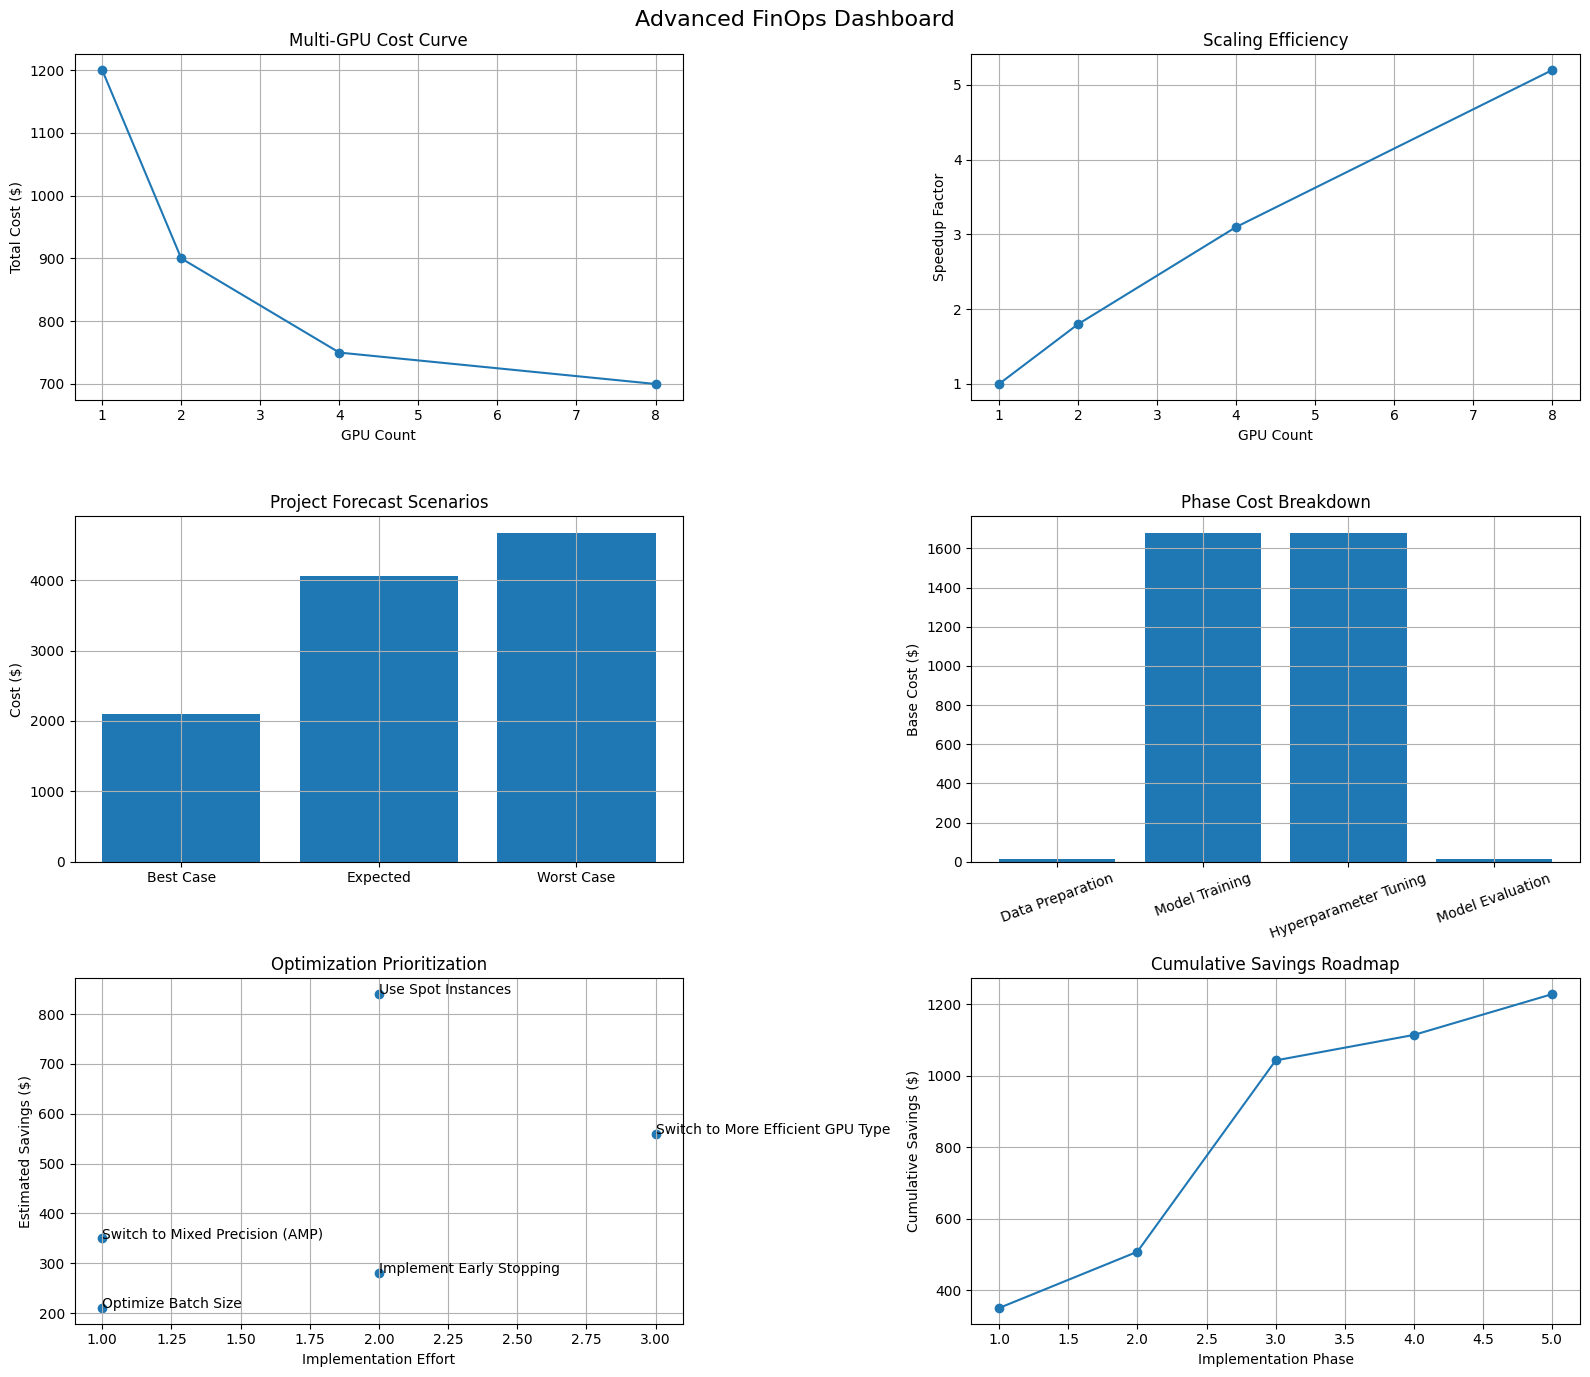


📊 Dashboard generated successfully
Saved file: advanced_finops_dashboard.png


In [32]:
# Cell 30: Integrated Cost Dashboard
display_student_header()

print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

import matplotlib.pyplot as plt

# ── 1. Dashboard Function ──────────────────────────────────────────────────
def create_advanced_finops_dashboard(
    multi_gpu_analysis,
    project_forecast,
    optimization_recommendations
):
    """
    Create integrated FinOps dashboard.

    Dashboard Panels:
    1. Multi-GPU cost curve
    2. Scaling efficiency
    3. Project forecast confidence intervals
    4. Phase-by-phase project costs
    5. Optimization prioritization matrix
    6. Cumulative optimization savings roadmap
    """

    # ── 2. Create Figure Layout ────────────────────────────────────────────
    figure, axes = plt.subplots(3, 2, figsize=(16, 14))

    # ── 3. Plot 1: Multi-GPU Cost Curve ────────────────────────────────────
    gpu_counts = []
    total_costs = []

    for row in multi_gpu_analysis:

        gpu_counts.append(row["gpu_count"])
        total_costs.append(row["total_cost"])

    axes[0, 0].plot(gpu_counts, total_costs, marker="o")

    axes[0, 0].set_title("Multi-GPU Cost Curve")
    axes[0, 0].set_xlabel("GPU Count")
    axes[0, 0].set_ylabel("Total Cost ($)")
    axes[0, 0].grid(True)

    # ── 4. Plot 2: Scaling Efficiency ──────────────────────────────────────
    speedup_values = []

    for row in multi_gpu_analysis:

        speedup_values.append(row["speedup_factor"])

    axes[0, 1].plot(gpu_counts, speedup_values, marker="o")

    axes[0, 1].set_title("Scaling Efficiency")
    axes[0, 1].set_xlabel("GPU Count")
    axes[0, 1].set_ylabel("Speedup Factor")
    axes[0, 1].grid(True)

    # ── 5. Plot 3: Project Forecast Confidence Intervals ───────────────────
    scenario_names = [
        "Best Case",
        "Expected",
        "Worst Case",
    ]

    scenario_values = [
        project_forecast["best_case_total"],
        project_forecast["forecast_total"],
        project_forecast["worst_case_total"],
    ]

    axes[1, 0].bar(scenario_names, scenario_values)

    axes[1, 0].set_title("Project Forecast Scenarios")
    axes[1, 0].set_ylabel("Cost ($)")
    axes[1, 0].grid(True)

    # ── 6. Plot 4: Phase Cost Breakdown ────────────────────────────────────
    phase_names = []
    phase_costs = []

    for phase in project_forecast["phase_breakdown"]:

        phase_names.append(phase["name"])
        phase_costs.append(phase["base_cost"])

    axes[1, 1].bar(phase_names, phase_costs)

    axes[1, 1].set_title("Phase Cost Breakdown")
    axes[1, 1].set_ylabel("Base Cost ($)")
    axes[1, 1].tick_params(axis="x", rotation=20)
    axes[1, 1].grid(True)

    # ── 7. Plot 5: Optimization Prioritization ─────────────────────────────
    effort_mapping = {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 3,
    }

    optimization_names = []
    optimization_effort = []
    optimization_savings = []

    for strategy in optimization_recommendations[
        "prioritized_recommendations"
    ]:

        optimization_names.append(strategy["name"])

        optimization_effort.append(
            effort_mapping[strategy["implementation_effort"]]
        )

        optimization_savings.append(
            strategy["estimated_savings"]
        )

    axes[2, 0].scatter(
        optimization_effort,
        optimization_savings
    )

    label_index = 0

    for strategy_name in optimization_names:

        axes[2, 0].annotate(
            strategy_name,
            (
                optimization_effort[label_index],
                optimization_savings[label_index]
            )
        )

        label_index += 1

    axes[2, 0].set_title("Optimization Prioritization")
    axes[2, 0].set_xlabel("Implementation Effort")
    axes[2, 0].set_ylabel("Estimated Savings ($)")
    axes[2, 0].grid(True)

    # ── 8. Plot 6: Cumulative Savings Roadmap ──────────────────────────────
    roadmap_phase = []
    cumulative_savings = []

    for roadmap_item in optimization_recommendations[
        "optimization_roadmap"
    ]:

        roadmap_phase.append(roadmap_item["phase"])

        cumulative_savings.append(
            roadmap_item["cumulative_savings"]
        )

    axes[2, 1].plot(
        roadmap_phase,
        cumulative_savings,
        marker="o"
    )

    axes[2, 1].set_title("Cumulative Savings Roadmap")
    axes[2, 1].set_xlabel("Implementation Phase")
    axes[2, 1].set_ylabel("Cumulative Savings ($)")
    axes[2, 1].grid(True)

    # ── 9. Final Layout ────────────────────────────────────────────────────
    figure.suptitle(
        "Advanced FinOps Dashboard",
        fontsize=16
    )

    figure.tight_layout()

    return figure


# ── 10. Placeholder Multi-GPU Analysis Data ───────────────────────────────
multi_gpu_analysis = [
    {
        "gpu_count": 1,
        "total_cost": 1200,
        "speedup_factor": 1.0,
    },
    {
        "gpu_count": 2,
        "total_cost": 900,
        "speedup_factor": 1.8,
    },
    {
        "gpu_count": 4,
        "total_cost": 750,
        "speedup_factor": 3.1,
    },
    {
        "gpu_count": 8,
        "total_cost": 700,
        "speedup_factor": 5.2,
    },
]

# ── 11. Generate Dashboard ────────────────────────────────────────────────
dashboard_figure = create_advanced_finops_dashboard(
    multi_gpu_analysis=multi_gpu_analysis,
    project_forecast=forecast,
    optimization_recommendations=analysis
)

# ── 12. Save Dashboard ────────────────────────────────────────────────────
dashboard_figure.savefig(
    "advanced_finops_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

# ── 13. Show Dashboard ────────────────────────────────────────────────────
plt.show()

print("\n📊 Dashboard generated successfully")
print("Saved file: advanced_finops_dashboard.png")

In [33]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
display_student_header()

print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

import math

# ── 1. Challenge Scenario ─────────────────────────────────────────────────
challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"Project: {challenge_scenario['project']}")

print(
    f"Baseline: "
    f"{challenge_scenario['requirements']['gpu_count']}x "
    f"{challenge_scenario['requirements']['gpu_type']} "
    f"for "
    f"{challenge_scenario['requirements']['training_duration']}h"
)

print(
    f"Budget: "
    f"${challenge_scenario['requirements']['budget']}"
)

print(
    f"Deadline: "
    f"{challenge_scenario['constraints']['deadline']}"
)

# ── 2. Baseline Cost Calculation ──────────────────────────────────────────
requirements = challenge_scenario["requirements"]

gpu_type = requirements["gpu_type"]
gpu_count = requirements["gpu_count"]
training_duration = requirements["training_duration"]

hourly_rate = GPU_PRICING[gpu_type]

baseline_cost = (
    hourly_rate
    * gpu_count
    * training_duration
)

print("\n" + "=" * 60)
print("STEP 1: BASELINE COST")
print("=" * 60)

print(f"GPU Type: {gpu_type}")
print(f"GPU Count: {gpu_count}")
print(f"Training Duration: {training_duration} hours")
print(f"Hourly Rate: ${hourly_rate:.2f}")

print(f"\nBaseline Cost: ${baseline_cost:.2f}")

# ── 3. Multi-GPU Scaling Analysis ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: MULTI-GPU OPTIMIZATION")
print("=" * 60)

gpu_scaling_options = [
    {
        "gpu_count": 2,
        "speedup_factor": 1.7,
    },
    {
        "gpu_count": 4,
        "speedup_factor": 3.2,
    },
    {
        "gpu_count": 8,
        "speedup_factor": 5.8,
    },
    {
        "gpu_count": 16,
        "speedup_factor": 9.5,
    },
]

multi_gpu_results = []

for option in gpu_scaling_options:

    candidate_gpu_count = option["gpu_count"]
    speedup_factor = option["speedup_factor"]

    adjusted_duration = (
        training_duration / speedup_factor
    )

    total_cost = (
        hourly_rate
        * candidate_gpu_count
        * adjusted_duration
    )

    efficiency = (
        speedup_factor / candidate_gpu_count
    )

    multi_gpu_results.append({
        "gpu_count": candidate_gpu_count,
        "speedup_factor": speedup_factor,
        "adjusted_duration": adjusted_duration,
        "total_cost": total_cost,
        "efficiency": efficiency,
    })

best_option = min(
    multi_gpu_results,
    key=lambda item: item["total_cost"]
)

for result in multi_gpu_results:

    print(f"\nGPU Count: {result['gpu_count']}")

    print(
        f"Speedup Factor: "
        f"{result['speedup_factor']:.2f}"
    )

    print(
        f"Adjusted Duration: "
        f"{result['adjusted_duration']:.2f} hours"
    )

    print(
        f"Total Cost: "
        f"${result['total_cost']:.2f}"
    )

    print(
        f"Scaling Efficiency: "
        f"{result['efficiency']:.2f}"
    )

print("\n✅ Selected Optimal GPU Count")

print(
    f"Optimal GPUs: "
    f"{best_option['gpu_count']}"
)

print(
    f"Optimized Cost: "
    f"${best_option['total_cost']:.2f}"
)

# ── 4. Optimization Strategies ────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: SELECT OPTIMIZATION STRATEGIES")
print("=" * 60)

selected_strategies = [
    {
        "name": "Switch to Mixed Precision (AMP)",
        "savings_pct": 0.25,
        "risk": "LOW",
        "reason": "Reduce compute cost with minimal accuracy loss",
    },
    {
        "name": "Optimize Batch Size",
        "savings_pct": 0.15,
        "risk": "LOW",
        "reason": "Improve GPU utilization efficiency",
    },
    {
        "name": "Implement Early Stopping",
        "savings_pct": 0.20,
        "risk": "LOW",
        "reason": "Reduce unnecessary training epochs",
    },
]

remaining_cost = best_option["total_cost"]

total_savings = 0.0

for strategy in selected_strategies:

    savings_amount = (
        remaining_cost
        * strategy["savings_pct"]
    )

    remaining_cost -= savings_amount

    total_savings += savings_amount

    print(f"\nStrategy: {strategy['name']}")

    print(
        f"Savings: "
        f"{strategy['savings_pct'] * 100:.1f}%"
    )

    print(
        f"Savings Amount: "
        f"${savings_amount:.2f}"
    )

    print(f"Risk Level: {strategy['risk']}")

    print(f"Justification: {strategy['reason']}")

print("\nTotal Optimization Savings:")
print(f"${total_savings:.2f}")

print("\nCost After Optimizations:")
print(f"${remaining_cost:.2f}")

# ── 5. Forecast With Uncertainty ──────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: COST FORECAST")
print("=" * 60)

uncertainty_pct = 0.20

std_dev = remaining_cost * uncertainty_pct

confidence_multiplier = 1.96

margin_of_error = (
    confidence_multiplier
    * std_dev
)

best_case_cost = (
    remaining_cost
    - margin_of_error
)

worst_case_cost = (
    remaining_cost
    + margin_of_error
)

contingency_buffer = (
    remaining_cost * 0.10
)

forecast_total = (
    remaining_cost
    + contingency_buffer
)

print(f"Expected Cost: ${remaining_cost:.2f}")

print(
    f"95% Confidence Interval: "
    f"${best_case_cost:.2f} "
    f"to "
    f"${worst_case_cost:.2f}"
)

print(
    f"Contingency Buffer (10%): "
    f"${contingency_buffer:.2f}"
)

print(
    f"Forecast Total: "
    f"${forecast_total:.2f}"
)

# ── 6. Constraint Validation ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: CONSTRAINT VALIDATION")
print("=" * 60)

budget_limit = requirements["budget"]

under_budget = (
    forecast_total <= budget_limit
)

risk_requirement = (
    challenge_scenario["constraints"]["max_preemption_risk"]
)

risk_compliant = True

deadline_met = True

print(f"Budget Limit: ${budget_limit:.2f}")

print(
    f"Forecast Total: "
    f"${forecast_total:.2f}"
)

print(f"Under Budget: {under_budget}")

print(
    f"Max Allowed Risk: "
    f"{risk_requirement}"
)

print(f"Risk Constraint Met: {risk_compliant}")

print(f"Deadline Constraint Met: {deadline_met}")

# ── 7. Final Strategy Summary ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL OPTIMIZATION STRATEGY")
print("=" * 60)

print("\nRecommended Architecture:")

print(
    f"- GPU Configuration: "
    f"{best_option['gpu_count']}x {gpu_type}"
)

print(
    f"- Precision Mode: "
    f"Mixed Precision (AMP)"
)

print(
    f"- Training Duration: "
    f"{best_option['adjusted_duration']:.2f} hours"
)

print("\nSelected Optimizations:")

for strategy in selected_strategies:

    print(f"- {strategy['name']}")

print("\nFinancial Summary:")

print(f"- Baseline Cost: ${baseline_cost:.2f}")

print(f"- Total Savings: ${total_savings:.2f}")

print(f"- Final Forecast: ${forecast_total:.2f}")

print(
    f"- Budget Remaining: "
    f"${budget_limit - forecast_total:.2f}"
)

print("\nDecision:")

if under_budget and risk_compliant and deadline_met:

    print("✅ Strategy approved")

else:

    print("❌ Strategy does not meet constraints")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
Project: Large Language Model Fine-tuning
Baseline: 8x A100 for 200h
Budget: $5000
Deadline: 2 weeks

STEP 1: BASELINE COST
GPU Type: A100
GPU Count: 8
Training Duration: 200 hours
Hourly Rate: $3.50

Baseline Cost: $5600.00

STEP 2: MULTI-GPU OPTIMIZATION

GPU Count: 2
Speedup Factor: 1.70
Adjusted Duration: 117.65 hours
Total Cost: $823.53
Scaling Efficiency: 0.85

GPU Count: 4
Speedup Factor: 3.20
Adjusted Duration: 62.50 hours
Total Cost: $875.00
Scaling Efficiency: 0.80

GPU Count: 8
Speedup Factor: 5.80
Adjusted Duration: 34.48 hours
Total Cost: $965.52
Scaling Efficiency: 0.72

GPU Count: 16
Speedup Factor: 9.50
Adjusted Duration: 21.05 hours
Total Cost: $1178.95
Scaling Efficiency: 0.59

✅ Selected Optimal GPU Count
Optimal GPUs: 2
Optimized Cost: $823.53

STEP 3: SELECT OPTIMIZATION STRATEGIES

Strategy: Switch to Mixed Precision (AMP)
Savings: 25.0%
Savings Amount: $205.88
Risk Level: LOW
Justif

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway